<a href="https://colab.research.google.com/github/owlmt/QuantumSecurity/blob/main/Shor_Factoring_N21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compiled Shor's Algorithm for $N = 21$ on Aer
### Reproducing Skosana & Tame, *Sci. Rep.* **11**, 16599 (2021)

This notebook reproduces the **order-finding / factoring** demonstration from
*"Demonstration of Shor's factoring algorithm for N = 21 on IBM quantum processors"*
(https://doi.org/10.1038/s41598-021-95973-w), using the **Aer statevector simulator**.

**What we reproduce**
- The compiled 5-qubit construction: 3 control qubits + 2 work qubits, with the work
  register encoding the three reachable levels $\{|1\rangle,|4\rangle,|16\rangle\}\to\{|00\rangle,|01\rangle,|10\rangle\}$.
- Choice $a=4,\;N=21$, giving order $r=3$.
- Output peaks at $000,\,011,\,101$, continued-fraction recovery of $r=3$, and the
  factors $\gcd(4^{3/2}\pm1,\,21)=3,7$.

**Honest framing (Aer vs. real hardware).** The paper ran on real IBM devices
(`ibmq_casablanca`, `ibmq_toronto`) where noise degrades the peaks (state fidelity $\approx0.70$,
peaks $\sim16\text{–}19\%$ instead of the ideal $25\%$). Here we use the **ideal noiseless
simulator**, so we see the clean ideal distribution. To mimic hardware you would add an
Aer `NoiseModel`. The paper's real contribution — replacing Toffoli gates with relative-phase
**Margolus** gates to halve the CX count — is shown below as a circuit-cost comparison, but
the noiseless result is identical with either choice.

In [1]:
# Colab setup
!pip install -q qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00


## 1. The encoded modular-exponentiation unitary

Instead of evaluating $4^x \bmod 21$ on a 5-qubit work register, the compiled algorithm
works in the $\log_4$-encoded space on just **2 qubits**. Multiplication by $a=4$ permutes
the three levels cyclically:
$$4\cdot1=4,\quad 4\cdot4=16,\quad 4\cdot16=64\equiv1 \pmod{21}$$
i.e. on encoded indices $\{0{=}|1\rangle,\,1{=}|4\rangle,\,2{=}|16\rangle,\,3{=}\text{null}\}$ the map is the 3-cycle $0\to1\to2\to0$.

In [2]:
import numpy as np
from fractions import Fraction
from math import gcd
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

N, a, n_count = 21, 4, 3   # 3 control qubits = 3 bits of accuracy (the paper's compact, non-iterative choice)

def perm_unitary(mapping, dim=4):
    M = np.zeros((dim, dim))
    for src, dst in mapping.items():
        M[dst, src] = 1.0
    return M

# multiply-by-4 on encoded levels {|1>,|4>,|16>,null} -> 3-cycle (null fixed)
U = perm_unitary({0: 1, 1: 2, 2: 0, 3: 3})
assert np.allclose(U @ U.conj().T, np.eye(4)), "U must be unitary"
print("Encoded multiply-by-4 unitary (real part):")
print(U.real.astype(int))

Encoded multiply-by-4 unitary (real part):
[[0 0 1 0]
 [1 0 0 0]
 [0 1 0 0]
 [0 0 0 1]]


## 2. Build the order-finding circuit (QPE)

This is quantum phase estimation on $U$: Hadamard the 3 control qubits, apply
controlled-$U^{2^j}$, then the inverse QFT, then measure. The work register starts in
$|1\rangle=|00\rangle$.

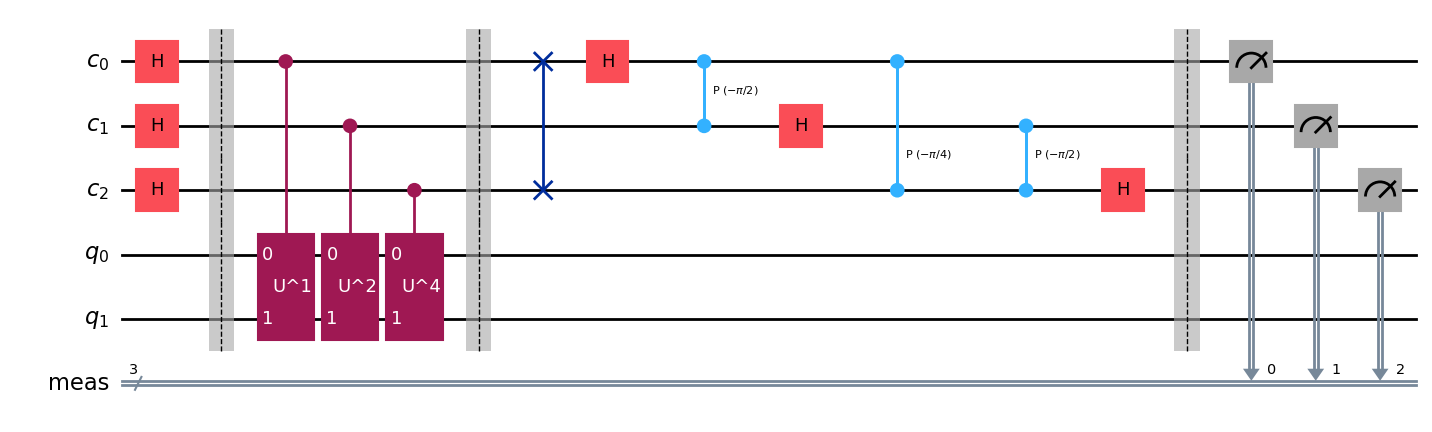

In [3]:
work = QuantumRegister(2, 'q')        # q0 q1  (work register)
ctrl = QuantumRegister(n_count, 'c')  # c0 c1 c2 (control register)
cl   = ClassicalRegister(n_count, 'meas')
qc = QuantumCircuit(ctrl, work, cl)

# work starts in |1> = |00> (already |00>); superpose the control register
qc.h(ctrl)
qc.barrier()

# controlled U^(2^j)
for j in range(n_count):
    power = 2 ** j
    Up = np.linalg.matrix_power(U, power)
    cU = UnitaryGate(Up, label=f"U^{power}").control(1)
    qc.append(cU, [ctrl[j], work[0], work[1]])
qc.barrier()

# inverse QFT on the control register (explicit, no library dependency)
def inverse_qft(circ, qubits):
    n = len(qubits)
    for i in range(n // 2):
        circ.swap(qubits[i], qubits[n - 1 - i])
    for j in range(n):
        for m in range(j):
            circ.cp(-np.pi / 2 ** (j - m), qubits[m], qubits[j])
        circ.h(qubits[j])

inverse_qft(qc, list(ctrl))
qc.barrier()
qc.measure(ctrl, cl)

qc.draw('mpl', fold=-1)

## 3. The paper's optimization: relative-phase (Margolus) Toffoli

A standard Toffoli decomposes into **6 CX** gates. The **Margolus gate** implements the
Toffoli up to a relative phase on $|101\rangle$ using only **3 CX** gates. In the circuit of
the paper that basis state is never encountered, so the substitution is *exactly* functionally
correct while halving the CX count. Below is the Margolus construction and a CX-count comparison
of a full Toffoli vs. its Margolus replacement.

CX in a standard Toffoli : 6
CX in a Margolus gate    : 3   (the paper's ~2x reduction)


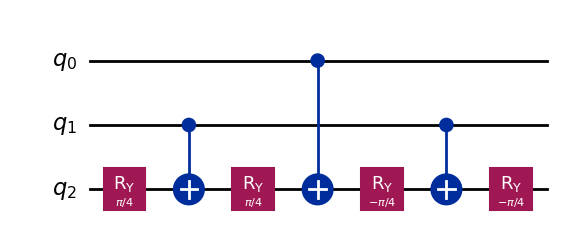

In [4]:
def margolus():
    # relative-phase Toffoli (controls 0,1 -> target 2), 3 CX + 4 single-qubit Ry
    g = QuantumCircuit(3, name="Margolus")
    g.ry(np.pi/4, 2)
    g.cx(1, 2)
    g.ry(np.pi/4, 2)
    g.cx(0, 2)
    g.ry(-np.pi/4, 2)
    g.cx(1, 2)
    g.ry(-np.pi/4, 2)
    return g

sim = AerSimulator()
tof = QuantumCircuit(3); tof.ccx(0,1,2)
tof_cx = transpile(tof, basis_gates=['cx','u'], optimization_level=0).count_ops().get('cx',0)
mar_cx = transpile(margolus().to_gate().definition, basis_gates=['cx','u'], optimization_level=0).count_ops().get('cx',0)
print(f"CX in a standard Toffoli : {tof_cx}")
print(f"CX in a Margolus gate    : {mar_cx}   (the paper's ~2x reduction)")
margolus().draw('mpl')

## 4. Run on the Aer simulator

Transpiled CX count: 17   depth: 41


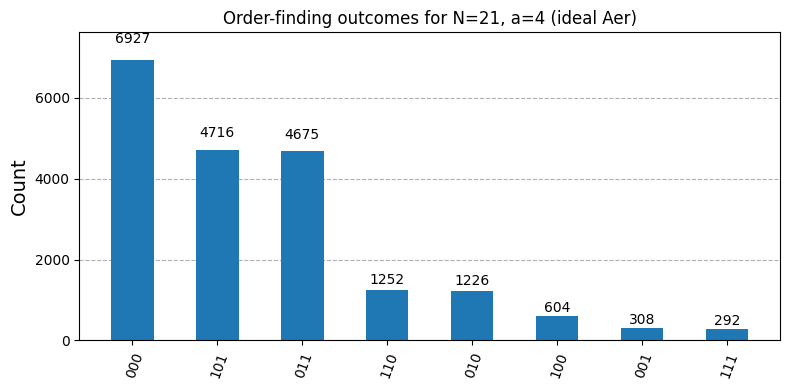

In [5]:
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=20000).result()
counts = result.get_counts()
print(f"Transpiled CX count: {tqc.count_ops().get('cx',0)}   depth: {tqc.depth()}")
plot_histogram(counts, sort='value_desc', figsize=(8,4),
               title='Order-finding outcomes for N=21, a=4 (ideal Aer)')

In [6]:
total = sum(counts.values())
print("Top outcomes (bitstring -> integer phi_s -> probability):")
print("Paper's ideal:  000->0.35,  011->0.25,  101->0.25\n")
for bs, c in sorted(counts.items(), key=lambda kv: -kv[1])[:5]:
    print(f"  {bs} -> {int(bs,2):>2}    p = {c/total:.3f}")

Top outcomes (bitstring -> integer phi_s -> probability):
Paper's ideal:  000->0.35,  011->0.25,  101->0.25

  000 ->  0    p = 0.346
  101 ->  5    p = 0.236
  011 ->  3    p = 0.234
  110 ->  6    p = 0.063
  010 ->  2    p = 0.061


## 5. Continued fractions $\to r \to$ factors

For each peak $\varphi_s$ we expand $\varphi=\varphi_s/2^n$ as a continued fraction and test
the convergents' denominators against $a^r \bmod N = 1$. As in the paper, both $\varphi=3/8$
and $\varphi=5/8$ yield the convergent $2/3 \Rightarrow r=3$.

Because $a=4$ is a perfect square, $a^{r/2}=4^{3/2}=8$ is an integer even though $r=3$ is odd,
so $\gcd(8\pm1,21)$ gives the factors directly.

In [7]:
def convergents(num, den):
    a_, b_ = num, den
    cf = []
    while b_:
        cf.append(a_ // b_); a_, b_ = b_, a_ % b_
    convs, h0, h1, k0, k1 = [], 0, 1, 1, 0
    for q in cf:
        h0, h1 = h1, q*h1 + h0
        k0, k1 = k1, q*k1 + k0
        convs.append((h1, k1))
    return convs

for bs, c in sorted(counts.items(), key=lambda kv: -kv[1]):
    if c/total < 0.05: continue
    phi = int(bs, 2)
    if phi == 0:
        print(f"  {bs}: phi=0  -> algorithm 'failure' outcome (expected, highest peak)")
        continue
    r = None
    for h, kdenom in convergents(phi, 2**n_count):
        if 0 < kdenom < N and pow(a, kdenom, N) == 1:
            r = kdenom; break
    print(f"  {bs}: phi={phi}/8  convergents={convergents(phi,2**n_count)}  -> r={r}")

r = 3
x = pow(a, r // 2, N) if r % 2 == 0 else int(round(a ** (r/2)))  # = 8 for a=4
f1, f2 = gcd(x - 1, N), gcd(x + 1, N)
print(f"\nr = {r},  a^(r/2) = {x}")
print(f"gcd({x}-1, 21) = {f1},   gcd({x}+1, 21) = {f2}")
print(f"==> nontrivial factors of 21: {sorted({f1, f2})}")

  000: phi=0  -> algorithm 'failure' outcome (expected, highest peak)
  101: phi=5/8  convergents=[(0, 1), (1, 1), (1, 2), (2, 3), (5, 8)]  -> r=3
  011: phi=3/8  convergents=[(0, 1), (1, 2), (1, 3), (3, 8)]  -> r=3
  110: phi=6/8  convergents=[(0, 1), (1, 1), (3, 4)]  -> r=None
  010: phi=2/8  convergents=[(0, 1), (1, 4)]  -> r=None

r = 3,  a^(r/2) = 8
gcd(8-1, 21) = 7,   gcd(8+1, 21) = 3
==> nontrivial factors of 21: [3, 7]


## Summary

| Quantity | Ideal (this notebook, Aer) | Paper, real IBM hardware |
|---|---|---|
| Peak $\|101\rangle$ probability | $\approx0.23$ (ideal $0.25$) | $\sim17\text{–}19\%$ |
| State fidelity | $1.0$ (noiseless) | $\approx0.70$ |
| Recovered order $r$ | $3$ | $3$ |
| Factors of 21 | $3,\,7$ | $3,\,7$ |

The noiseless simulator gives the clean ideal distribution; on real devices, noise lowers the
peaks but they remain distinguishable enough for continued fractions to recover $r=3$ and fully
factor 21 — the paper's central result. To study the hardware regime, attach an Aer
`NoiseModel` built from a backend's calibration data.

> **Scope note.** Reproducing $N=21$ demonstrates the *mechanism* of Shor's algorithm; it gives
> no practical capability against RSA-sized integers, which need thousands of logical qubits.